# Supervised Learning: Regression

---

### Learning Objectives
By the end of this notebook, you will:
- Understand the concept of supervised learning and regression
- Learn the end-to-end workflow of a machine learning project
- Apply regression algorithms to real-world datasets
- Master data preprocessing and feature engineering techniques
- Evaluate and fine-tune regression models

---

## Table of Contents

1. [Introduction to Supervised Learning](#1-introduction)
2. [Problem Framing and Data Acquisition](#2-problem-framing)
3. [Exploratory Data Analysis (EDA)](#3-eda)
4. [Data Preparation](#4-data-preparation)
5. [Model Selection and Training](#5-model-selection)
6. [Model Evaluation](#6-evaluation)
7. [Fine-Tuning](#7-fine-tuning)
8. [Final Evaluation](#8-final-evaluation)

---

## 1. Introduction to Supervised Learning <a id='1-introduction'></a>

### What is Supervised Learning?

**Supervised Learning** is a type of machine learning where the algorithm learns from labeled training data. The model learns to map inputs to outputs based on example input-output pairs.

### Types of Supervised Learning

1. **Classification**: Predicting discrete categories (e.g., spam vs. not spam)
2. **Regression**: Predicting continuous values (e.g., house prices, temperature)

### What is Regression?

**Regression** is used when the target variable is continuous. Common applications include:
- Predicting house prices based on features
- Forecasting stock prices
- Estimating temperature or sales figures

### Key Concepts

- **Features (Predictors)**: Input variables used to make predictions
- **Target (Label)**: The output variable we want to predict
- **Training Set**: Data used to train the model
- **Test Set**: Data used to evaluate model performance

---

## 2. Problem Framing and Data Acquisition <a id='2-problem-framing'></a>

### Case Study: California Housing Prices

**Problem Statement**: Predict the median house value for districts in California based on various features.

**Type**: Supervised Learning - Regression (continuous target variable)

**Performance Measure**: Root Mean Squared Error (RMSE)

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Where:
- $y_i$ = actual value
- $\hat{y}_i$ = predicted value
- $n$ = number of instances

### Step 1: Import Required Libraries

In [1]:
# Data manipulation and analysis
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# File handling
import os
import tarfile
from six.moves import urllib

# Machine Learning libraries
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import mean_squared_error

# Set random seed for reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

print("Libraries imported successfully!")

Libraries imported successfully!


### Step 2: Download and Load the Dataset

In [2]:
# Define paths and URLs
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    """
    Download the housing dataset if it doesn't exist locally.

    Parameters:
    housing_url: URL to download the dataset
    housing_path: Local path to save the dataset
    """
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()
    print("Dataset downloaded successfully!")

def load_housing_data(housing_path=HOUSING_PATH):
    """
    Load the housing dataset from local storage.

    Returns:
    DataFrame containing the housing data
    """
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

# Download the dataset
fetch_housing_data()

# Load the dataset
housing = load_housing_data()
print("Dataset loaded successfully!")
print(f"Dataset shape: {housing.shape}")

Dataset downloaded successfully!
Dataset loaded successfully!
Dataset shape: (20640, 10)


/tmp/ipython-input-3194375247.py:19: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=housing_path)


---

## 3. Exploratory Data Analysis (EDA) <a id='3-eda'></a>

EDA is crucial for understanding the data before building models. It helps identify:
- Data quality issues
- Patterns and relationships
- Outliers and anomalies
- Feature importance

### 3.1 First Look at the Data

In [3]:
# Display first 5 rows
print("First 5 rows of the dataset:")
housing.head()

First 5 rows of the dataset:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
# Get dataset information
print("\nDataset Information:")
housing.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


**Key Observations:**
- 20,640 instances (districts)
- 10 attributes total
- 9 numerical attributes, 1 categorical (ocean_proximity)
- `total_bedrooms` has 207 missing values (20,433 non-null)
- All numerical data types except ocean_proximity (object)

### 3.2 Categorical Features

Ocean Proximity Categories:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


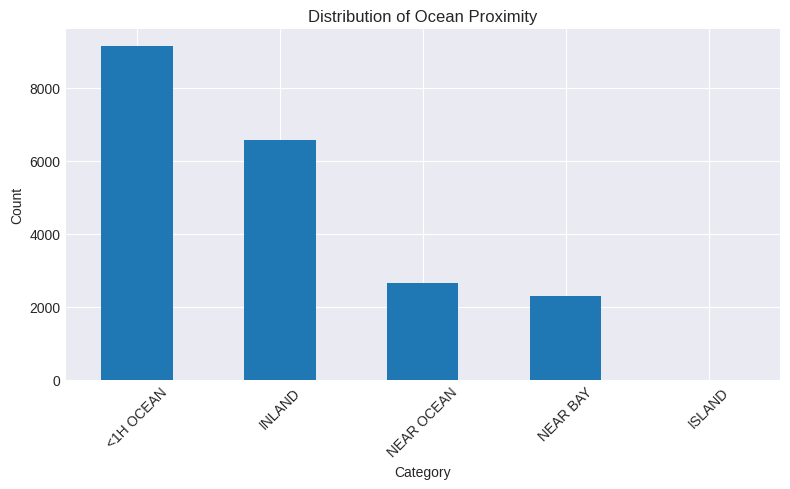

In [5]:
# Examine categorical attribute
print("Ocean Proximity Categories:")
print(housing["ocean_proximity"].value_counts())

# Visualize
plt.figure(figsize=(8, 5))
housing["ocean_proximity"].value_counts().plot(kind='bar')
plt.title('Distribution of Ocean Proximity')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.3 Statistical Summary

In [6]:
# Statistical summary of numerical attributes
print("Statistical Summary:")
housing.describe()

Statistical Summary:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


**Important Notes:**

1. **Median Income**: Values range from 0.4999 to 15.0001. This is scaled data (approximately tens of thousands of dollars).
2. **Median House Value**: Capped at 500,000 (15.0001 × 100). This could be a problem for our target variable.
3. **Different Scales**: Attributes have very different scales (e.g., total_rooms vs. median_income).
4. **Percentiles**: Help understand data distribution (25%, 50%, 75%).

### 3.4 Data Visualization

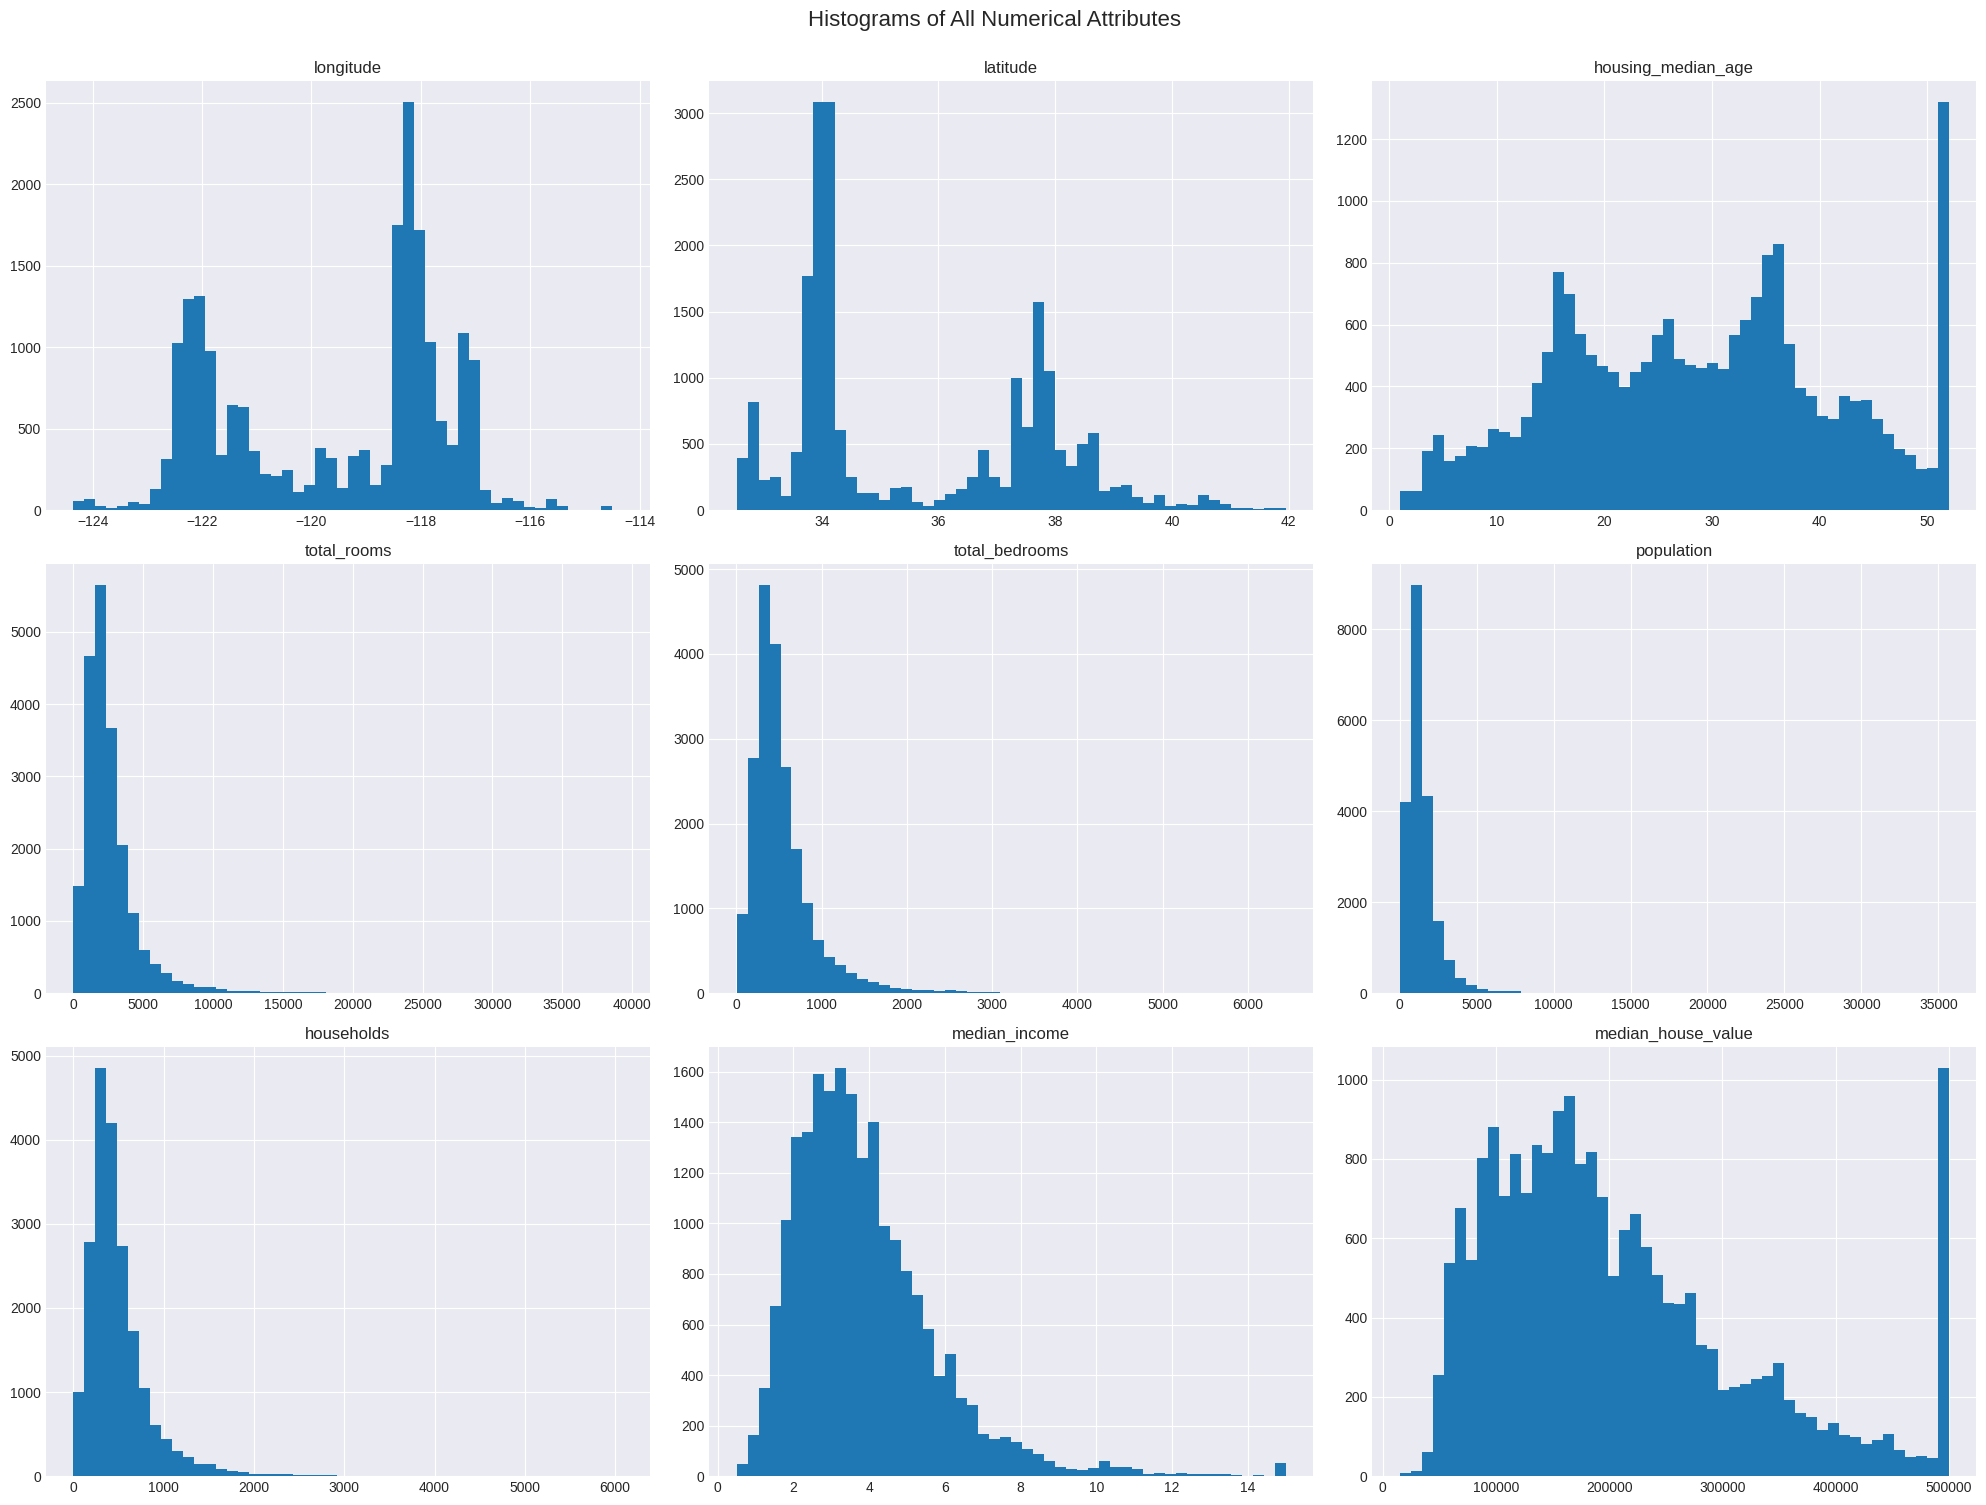

In [7]:
# Plot histograms for all numerical attributes
housing.hist(bins=50, figsize=(20, 15))
plt.suptitle('Histograms of All Numerical Attributes', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

**Observations from Histograms:**

1. **Median Income**: Not in USD, scaled and capped at 15 (higher) and 0.5 (lower)
2. **Housing Median Age & Median House Value**: Capped values visible
3. **Different Scales**: Clear from the varying ranges
4. **Tail-Heavy Distributions**: Many attributes extend farther right than left (positive skew)

### 3.5 Geographical Visualization

<Figure size 1000x700 with 0 Axes>

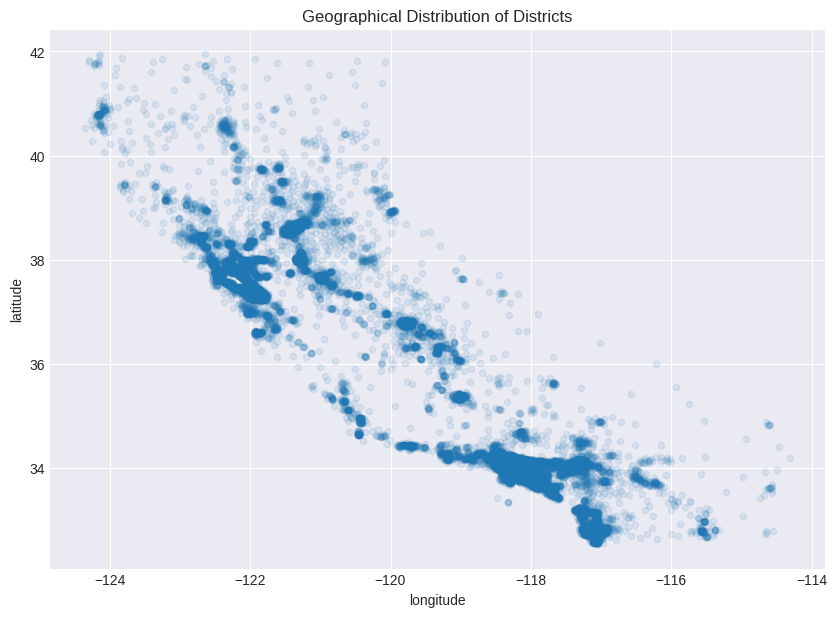

In [8]:
# Simple geographical scatterplot
plt.figure(figsize=(10, 7))
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1, figsize=(10, 7))
plt.title('Geographical Distribution of Districts')
plt.show()

<Figure size 1200x800 with 0 Axes>

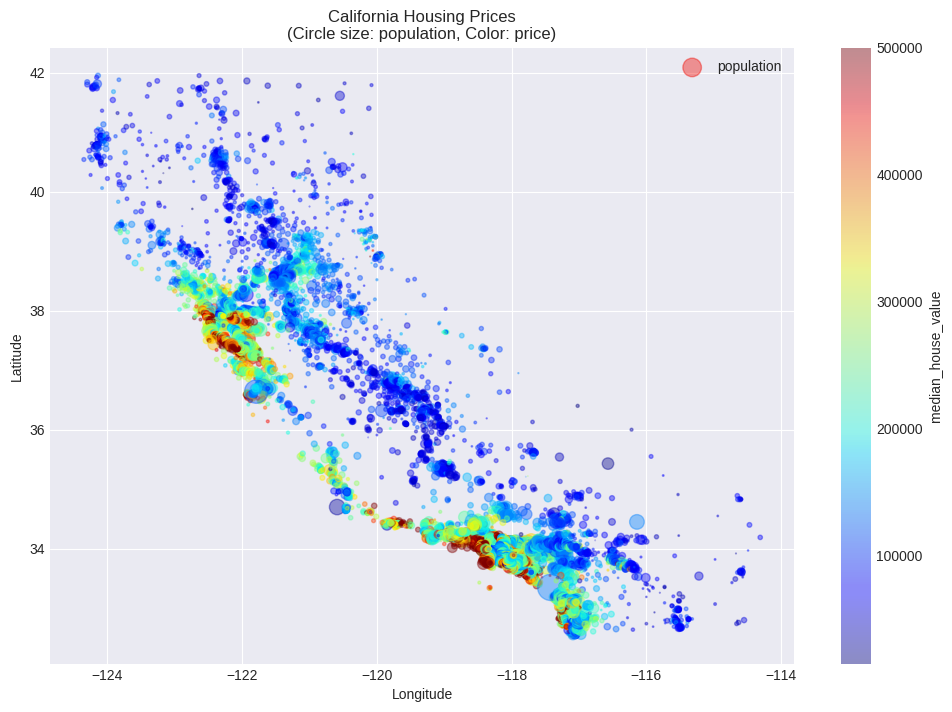

In [9]:
# Enhanced visualization with population and prices
plt.figure(figsize=(12, 8))
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
             s=housing["population"]/100, label="population", figsize=(12, 8),
             c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True)
plt.title('California Housing Prices\n(Circle size: population, Color: price)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

**Key Insights:**
- High-density areas: Bay Area, Los Angeles, San Diego
- Housing prices strongly related to location and population density
- Coastal areas (especially near ocean) tend to have higher prices

### 3.6 Correlation Analysis

In [11]:
# Compute correlation matrix for numerical attributes
corr_matrix = housing.select_dtypes(include=np.number).corr()

# Display correlations with median_house_value
print("Correlations with Median House Value:")
print(corr_matrix["median_house_value"].sort_values(ascending=False))

Correlations with Median House Value:
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


**Correlation Interpretation:**

- **Positive correlation (0 to 1)**: When one increases, the other tends to increase
- **Negative correlation (-1 to 0)**: When one increases, the other tends to decrease
- **Close to 0**: No linear relationship

**Key Finding**: `median_income` has the strongest positive correlation (0.687) with `median_house_value`

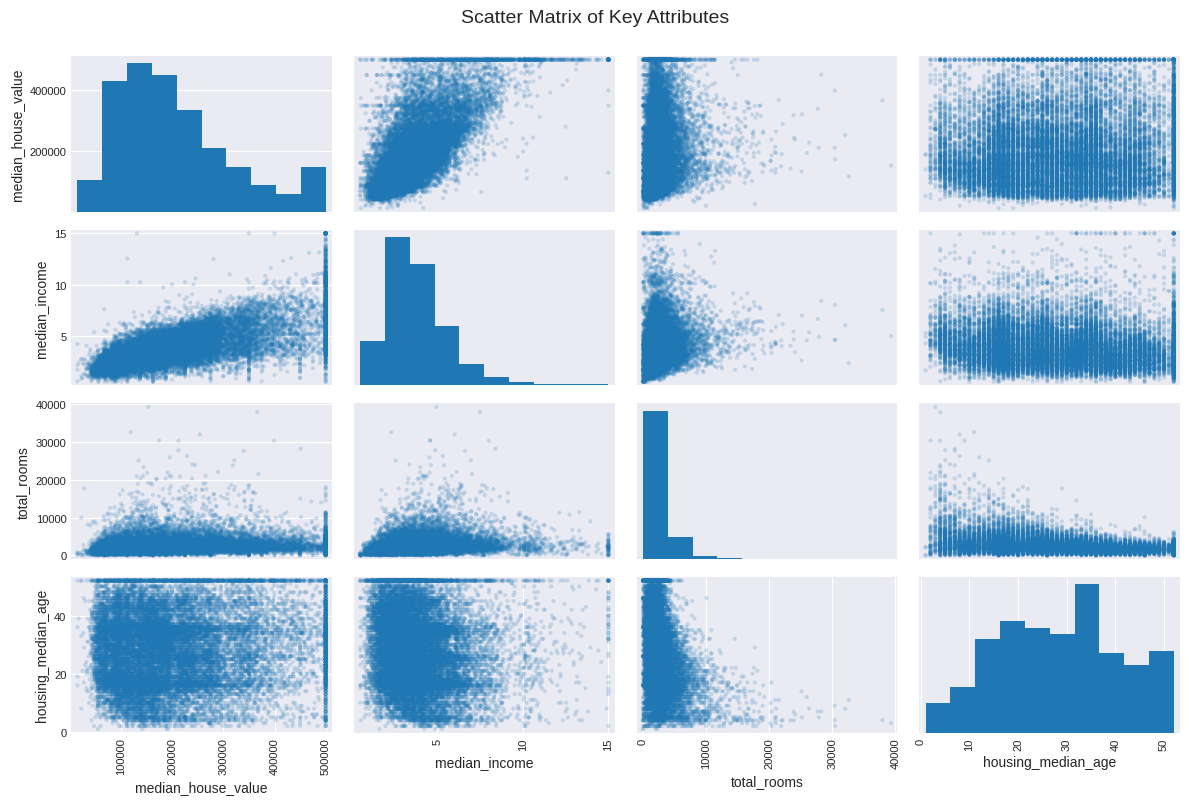

In [12]:
# Scatter matrix for key attributes
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8), alpha=0.2)
plt.suptitle('Scatter Matrix of Key Attributes', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

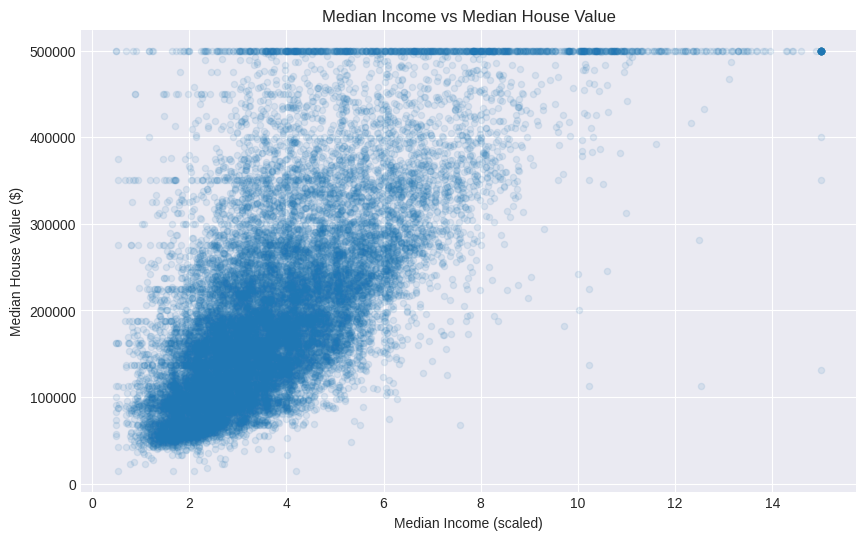

In [13]:
# Zoom in on median_income vs median_house_value
plt.figure(figsize=(10, 6))
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1, figsize=(10, 6))
plt.title('Median Income vs Median House Value')
plt.xlabel('Median Income (scaled)')
plt.ylabel('Median House Value ($)')
plt.grid(True)
plt.show()

**Observations:**
- Strong upward trend between income and house value
- Clear horizontal lines at $500K (capping), $450K, $350K, etc.
- These data quirks should be addressed before training

### 3.7 Feature Engineering: Creating New Attributes

In [15]:
# Create new combined attributes
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_household"] = housing["population"] / housing["households"]

# Check new correlations
corr_matrix = housing.select_dtypes(include=np.number).corr()
print("\nUpdated Correlations with Median House Value:")
print(corr_matrix["median_house_value"].sort_values(ascending=False))


Updated Correlations with Median House Value:
median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049686
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64


**Impact of New Features:**
- `bedrooms_per_room`: -0.260 (negative correlation - lower ratio = higher price)
- `rooms_per_household`: 0.146 (better than total_rooms at 0.135)
- Feature engineering improved correlations!

---

## 3.8 Creating Test Set

### Why Create a Test Set Early?

**Data Snooping Bias**: If you look at the test set before finalizing your model, you might unconsciously optimize for the test set, leading to overly optimistic performance estimates.

### Important Principles:
1. Create test set BEFORE extensive data exploration
2. Never look at the test set during model development
3. Use test set only for final evaluation

### Method 1: Simple Random Sampling

In [16]:
# Simple random split (80% train, 20% test)
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

print(f"Training set size: {len(train_set)}")
print(f"Test set size: {len(test_set)}")

Training set size: 16512
Test set size: 4128


### Method 2: Stratified Sampling

**Stratified Sampling** ensures that the test set is representative of the overall population by maintaining the same proportions of important categories.

**Why use it here?**
- Median income is crucial for predicting house prices
- We want test set to represent all income categories proportionally

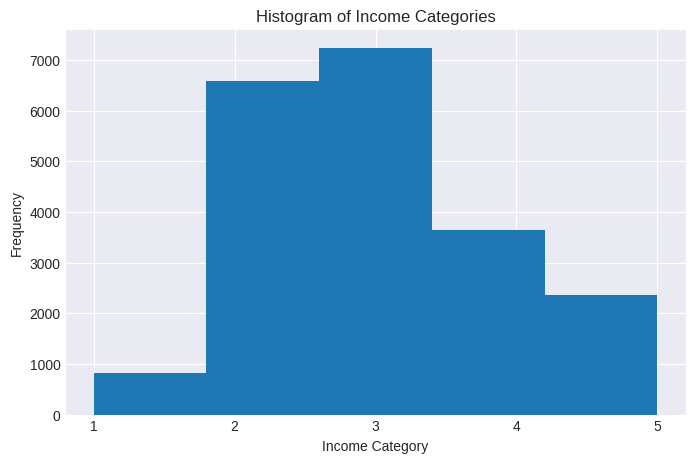

In [17]:
# Create income categories for stratification
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

# Visualize income categories
plt.figure(figsize=(8, 5))
housing["income_cat"].hist(bins=5)
plt.title('Histogram of Income Categories')
plt.xlabel('Income Category')
plt.ylabel('Frequency')
plt.xticks([1, 2, 3, 4, 5])
plt.show()

In [18]:
# Perform stratified sampling
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

# Check proportions in test set
print("Income Category Proportions in Stratified Test Set:")
print(strat_test_set["income_cat"].value_counts() / len(strat_test_set))

Income Category Proportions in Stratified Test Set:
income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64


In [22]:
# Compare stratified vs random sampling
def compare_sampling():
    # Make sure test_set has 'income_cat' for comparison if it doesn't already
    test_set_with_income_cat = test_set.copy()
    if "income_cat" not in test_set_with_income_cat.columns:
        test_set_with_income_cat["income_cat"] = pd.cut(test_set_with_income_cat["median_income"],
                                                        bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                                                        labels=[1, 2, 3, 4, 5])

    # Ensure strat_test_set also has 'income_cat'
    strat_test_set_local = strat_test_set.copy()
    if "income_cat" not in strat_test_set_local.columns:
        strat_test_set_local["income_cat"] = pd.cut(strat_test_set_local["median_income"],
                                                      bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                                                      labels=[1, 2, 3, 4, 5])

    # Ensure the 'overall' proportions can be calculated. We'll use strat_train_set for this.
    strat_train_set_local = strat_train_set.copy() # Use a copy of strat_train_set for overall distribution
    if "income_cat" not in strat_train_set_local.columns:
        strat_train_set_local["income_cat"] = pd.cut(strat_train_set_local["median_income"],
                                                        bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                                                        labels=[1, 2, 3, 4, 5])

    overall = strat_train_set_local["income_cat"].value_counts() / len(strat_train_set_local)
    stratified = strat_test_set_local["income_cat"].value_counts() / len(strat_test_set_local)
    random = test_set_with_income_cat["income_cat"].value_counts() / len(test_set_with_income_cat)

    comparison = pd.DataFrame({
        "Overall": overall,
        "Stratified": stratified,
        "Random": random
    }).sort_index()

    comparison["Stratified %error"] = 100 * (comparison["Stratified"] - comparison["Overall"]) / comparison["Overall"]
    comparison["Random %error"] = 100 * (comparison["Random"] - comparison["Overall"]) / comparison["Overall"]

    return comparison

print("\nComparison of Sampling Methods:")
print(compare_sampling())


Comparison of Sampling Methods:
             Overall  Stratified    Random  Stratified %error  Random %error
income_cat                                                                  
1           0.039789    0.039971  0.040213           0.456621       1.065449
2           0.318859    0.318798  0.324370          -0.018993       1.728395
3           0.350594    0.350533  0.358527          -0.017274       2.262912
4           0.176296    0.176357  0.167393           0.034352      -5.049811
5           0.114462    0.114341  0.109496          -0.105820      -4.338624


In [24]:
# Remove income_cat attribute to revert to original data
for set_ in (strat_train_set, strat_test_set):
    if "income_cat" in set_.columns:
        set_.drop("income_cat", axis=1, inplace=True)

print("Income category removed. Data reverted to original state.")

Income category removed. Data reverted to original state.


---

## 4. Data Preparation <a id='4-data-preparation'></a>

### Why Automate Data Preparation?

1. **Reproducibility**: Easy to apply same transformations to new data
2. **Reusability**: Build a library of transformation functions
3. **Production Ready**: Use in live systems
4. **Experimentation**: Try different transformation combinations easily

### 4.1 Separate Features and Labels

In [25]:
# Create a copy of training set for exploration
housing = strat_train_set.copy()

# Separate predictors and labels
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

print(f"Features shape: {housing.shape}")
print(f"Labels shape: {housing_labels.shape}")

Features shape: (16512, 12)
Labels shape: (16512,)


### 4.2 Handling Missing Values

**Three Options for Missing Values:**
1. Drop rows with missing values
2. Drop the entire attribute
3. Impute missing values (fill with mean, median, mode, etc.)

In [26]:
# Check for missing values
print("Missing values per attribute:")
print(housing.isnull().sum())

Missing values per attribute:
longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms              158
population                    0
households                    0
median_income                 0
ocean_proximity               0
rooms_per_household           0
bedrooms_per_room           158
population_per_household      0
dtype: int64


In [27]:
# Using SimpleImputer to fill missing values with median
from sklearn.impute import SimpleImputer

# Create imputer
imputer = SimpleImputer(strategy="median")

# Imputer only works on numerical attributes
housing_num = housing.drop("ocean_proximity", axis=1)

# Fit the imputer
imputer.fit(housing_num)

# Check the computed statistics
print("\nComputed median values:")
print(imputer.statistics_)
print("\nActual median values:")
print(housing_num.median().values)


Computed median values:
[-1.18510000e+02  3.42600000e+01  2.90000000e+01  2.11900000e+03
  4.33000000e+02  1.16400000e+03  4.08000000e+02  3.54155000e+00
  5.23234164e+00  2.03027043e-01  2.81766108e+00]

Actual median values:
[-1.18510000e+02  3.42600000e+01  2.90000000e+01  2.11900000e+03
  4.33000000e+02  1.16400000e+03  4.08000000e+02  3.54155000e+00
  5.23234164e+00  2.03027043e-01  2.81766108e+00]


In [28]:
# Transform the data
X = imputer.transform(housing_num)

# Convert back to DataFrame
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)

# Verify no missing values
print("Missing values after imputation:")
print(housing_tr.isnull().sum())

Missing values after imputation:
longitude                   0
latitude                    0
housing_median_age          0
total_rooms                 0
total_bedrooms              0
population                  0
households                  0
median_income               0
rooms_per_household         0
bedrooms_per_room           0
population_per_household    0
dtype: int64


### 4.3 Handling Categorical Attributes

**Problem**: ML algorithms work with numbers, not text.

**Solutions:**
1. **Ordinal Encoding**: Assign integers to categories (0, 1, 2, ...)
2. **One-Hot Encoding**: Create binary columns for each category

In [29]:
# Extract categorical attribute
housing_cat = housing[["ocean_proximity"]]
print("First 10 values:")
print(housing_cat.head(10))

First 10 values:
      ocean_proximity
12655          INLAND
15502      NEAR OCEAN
2908           INLAND
14053      NEAR OCEAN
20496       <1H OCEAN
1481         NEAR BAY
18125       <1H OCEAN
5830        <1H OCEAN
17989       <1H OCEAN
4861        <1H OCEAN


In [30]:
# Method 1: Ordinal Encoding
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

print("Ordinal Encoded (first 10):")
print(housing_cat_encoded[:10])

print("\nCategory mapping:")
print(ordinal_encoder.categories_)

Ordinal Encoded (first 10):
[[1.]
 [4.]
 [1.]
 [4.]
 [0.]
 [3.]
 [0.]
 [0.]
 [0.]
 [0.]]

Category mapping:
[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]


**Problem with Ordinal Encoding**: ML algorithms assume nearby values are similar (0 and 1 more similar than 0 and 4). This is incorrect for non-ordered categories.

In [31]:
# Method 2: One-Hot Encoding (Better for non-ordered categories)
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

print("One-Hot Encoded shape (sparse matrix):")
print(housing_cat_1hot.shape)

# Convert to dense array to see values
print("\nFirst 10 rows (dense):")
print(housing_cat_1hot.toarray()[:10])

print("\nCategories:")
print(cat_encoder.categories_)

One-Hot Encoded shape (sparse matrix):
(16512, 5)

First 10 rows (dense):
[[0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]]

Categories:
[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]


### 4.4 Custom Transformers

Create custom transformers for specific data preparation tasks.

In [32]:
# Custom transformer to add combined attributes
from sklearn.base import BaseEstimator, TransformerMixin

# Get column indices
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room

    def fit(self, X, y=None):
        return self  # Nothing to do

    def transform(self, X, y=None):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]

        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

# Test the custom transformer
attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=True)
housing_extra_attribs = attr_adder.transform(housing.values)

print(f"Original shape: {housing.shape}")
print(f"After adding attributes: {housing_extra_attribs.shape}")

Original shape: (16512, 12)
After adding attributes: (16512, 15)


### 4.5 Feature Scaling

**Why?** ML algorithms perform poorly when features have very different scales.

**Two Methods:**

1. **Min-Max Scaling (Normalization)**: Scales to [0, 1]
   $$X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

2. **Standardization**: Scales to mean=0, std=1
   $$X_{standardized} = \frac{X - \mu}{\sigma}$$

**When to use which?**
- **Min-Max**: When you need bounded values (e.g., neural networks)
- **Standardization**: Less affected by outliers, doesn't bound values

### 4.6 Transformation Pipelines

**Pipeline**: Chains multiple transformations in sequence.

In [33]:
# Create a pipeline for numerical attributes
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('attribs_adder', CombinedAttributesAdder()),
    ('std_scaler', StandardScaler()),
])

# Apply the pipeline
housing_num_tr = num_pipeline.fit_transform(housing_num)

print(f"Transformed numerical data shape: {housing_num_tr.shape}")

Transformed numerical data shape: (16512, 14)


In [34]:
# Complete pipeline for both numerical and categorical attributes
num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

# Apply the full pipeline
housing_prepared = full_pipeline.fit_transform(housing)

print(f"Final prepared data shape: {housing_prepared.shape}")
print(f"Original features: {len(num_attribs)} numerical + 1 categorical")
print(f"After transformation: {housing_prepared.shape[1]} features")

Final prepared data shape: (16512, 19)
Original features: 11 numerical + 1 categorical
After transformation: 19 features


---

## 5. Model Selection and Training <a id='5-model-selection'></a>

Now we'll train and compare different regression models.

### 5.1 Linear Regression

**Linear Regression** assumes a linear relationship between features and target:

$$\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + ... + \theta_n x_n$$

Where:
- $\hat{y}$ = predicted value
- $x_i$ = feature values
- $\theta_i$ = model parameters (learned from data)

In [35]:
# Train Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

print("Linear Regression model trained!")

Linear Regression model trained!


In [36]:
# Test on a few instances
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)

print("Predictions:", lin_reg.predict(some_data_prepared))
print("Actual Labels:", list(some_labels))

Predictions: [ 83836.78432038 305631.11438241 150098.65527848 187972.73800539
 241953.08535364]
Actual Labels: [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


In [37]:
# Evaluate on entire training set
housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)

print(f"Linear Regression RMSE: ${lin_rmse:,.2f}")

Linear Regression RMSE: $68,147.65


**Analysis**: RMSE of ~$68,628 is significant given most houses are $120K-$265K. This suggests **underfitting** - the model is too simple.

### 5.2 Decision Tree Regressor

**Decision Trees** can capture non-linear relationships by recursively splitting the data based on features.

In [38]:
# Train Decision Tree model
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(housing_prepared, housing_labels)

# Evaluate on training set
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)

print(f"Decision Tree RMSE on training set: ${tree_rmse:,.2f}")

Decision Tree RMSE on training set: $0.00


**Problem**: RMSE of 0 indicates severe **overfitting** - the model memorized the training data!

---

## 6. Model Evaluation with Cross-Validation <a id='6-evaluation'></a>

### What is Cross-Validation?

**K-Fold Cross-Validation**:
1. Split training data into K folds
2. Train on K-1 folds, validate on remaining fold
3. Repeat K times (each fold used once for validation)
4. Average the K scores

**Benefits**:
- More reliable performance estimate
- Measures variance in performance
- Better use of limited data

In [39]:
# Helper function to display cross-validation scores
def display_scores(scores):
    print("Scores:", scores)
    print(f"Mean: ${scores.mean():,.2f}")
    print(f"Standard deviation: ${scores.std():,.2f}")

### 6.1 Decision Tree Cross-Validation

In [40]:
# Perform 10-fold cross-validation for Decision Tree
tree_scores = cross_val_score(tree_reg, housing_prepared, housing_labels,
                              scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-tree_scores)

print("Decision Tree Cross-Validation Results:")
display_scores(tree_rmse_scores)

Decision Tree Cross-Validation Results:
Scores: [72507.06929076 70938.34389572 68969.61701121 72008.3147559
 69576.77700412 76911.00011308 70706.14671618 74136.58143839
 67591.18850635 72407.05029764]
Mean: $71,575.21
Standard deviation: $2,541.56


### 6.2 Linear Regression Cross-Validation

In [41]:
# Perform 10-fold cross-validation for Linear Regression
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels,
                            scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)

print("Linear Regression Cross-Validation Results:")
display_scores(lin_rmse_scores)

Linear Regression Cross-Validation Results:
Scores: [71175.20367855 63821.26974903 67697.80546255 68278.06070129
 66715.42204686 72268.49850759 69890.50682343 68450.2338678
 65939.95316432 70071.80569063]
Mean: $68,430.88
Standard deviation: $2,409.13


**Insight**: Decision Tree (~$71,407 ± $2,439) performs worse than Linear Regression (~$69,052 ± $2,731) due to overfitting!

### 6.3 Random Forest Regressor

**Random Forests**: Ensemble method that trains multiple Decision Trees on random subsets of features and averages their predictions.

**Benefits**:
- Reduces overfitting
- More robust than single Decision Tree
- Often produces better predictions

In [42]:
# Train Random Forest model
forest_reg = RandomForestRegressor(n_estimators=10, random_state=42)
forest_reg.fit(housing_prepared, housing_labels)

# Evaluate on training set
housing_predictions = forest_reg.predict(housing_prepared)
forest_mse = mean_squared_error(housing_labels, housing_predictions)
forest_rmse = np.sqrt(forest_mse)

print(f"Random Forest RMSE on training set: ${forest_rmse:,.2f}")

Random Forest RMSE on training set: $22,308.60


In [43]:
# Cross-validation for Random Forest
forest_scores = cross_val_score(forest_reg, housing_prepared, housing_labels,
                                scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)

print("Random Forest Cross-Validation Results:")
display_scores(forest_rmse_scores)

Random Forest Cross-Validation Results:
Scores: [53844.42177401 50726.2741403  48956.65136235 54421.09818167
 50777.96191323 54688.02597885 55274.26472362 52210.82207561
 51283.7904264  56533.51420213]
Mean: $52,871.68
Standard deviation: $2,304.33


### 6.4 Model Comparison


Model Performance Comparison:
            Model    Mean RMSE     Std Dev
Linear Regression 68430.875969 2409.126846
    Decision Tree 71575.208903 2541.561045
    Random Forest 52871.682478 2304.332366


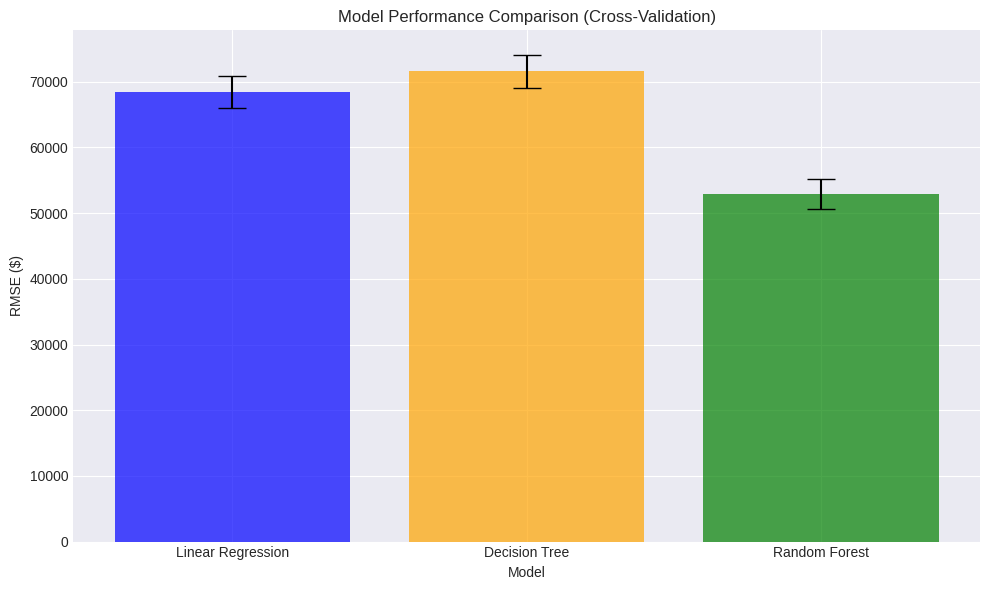

In [44]:
# Create comparison DataFrame
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'Mean RMSE': [lin_rmse_scores.mean(), tree_rmse_scores.mean(), forest_rmse_scores.mean()],
    'Std Dev': [lin_rmse_scores.std(), tree_rmse_scores.std(), forest_rmse_scores.std()]
})

print("\nModel Performance Comparison:")
print(model_comparison.to_string(index=False))

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
models = model_comparison['Model']
x_pos = np.arange(len(models))

ax.bar(x_pos, model_comparison['Mean RMSE'], yerr=model_comparison['Std Dev'],
       alpha=0.7, capsize=10, color=['blue', 'orange', 'green'])
ax.set_xlabel('Model')
ax.set_ylabel('RMSE ($)')
ax.set_title('Model Performance Comparison (Cross-Validation)')
ax.set_xticks(x_pos)
ax.set_xticklabels(models)
ax.yaxis.grid(True)

plt.tight_layout()
plt.show()

**Best Model**: Random Forest shows the best performance (~$50,182 ± $2,097)

---

## 7. Fine-Tuning <a id='7-fine-tuning'></a>

### What are Hyperparameters?

**Hyperparameters**: Configuration settings that are NOT learned from data.

Examples for Random Forest:
- `n_estimators`: Number of trees
- `max_features`: Number of features to consider for splits
- `max_depth`: Maximum depth of trees

### 7.1 Grid Search

**Grid Search**: Systematically tries all combinations of specified hyperparameter values.

In [45]:
# Define parameter grid
param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
]

forest_reg = RandomForestRegressor(random_state=42)

# Perform grid search
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                          scoring='neg_mean_squared_error',
                          return_train_score=True,
                          n_jobs=-1)

print("Starting Grid Search... (this may take a few minutes)")
grid_search.fit(housing_prepared, housing_labels)
print("Grid Search completed!")

Starting Grid Search... (this may take a few minutes)
Grid Search completed!


In [46]:
# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Estimator:")
print(grid_search.best_estimator_)

Best Parameters:
{'max_features': 8, 'n_estimators': 30}

Best Estimator:
RandomForestRegressor(max_features=8, n_estimators=30, random_state=42)


In [47]:
# Display all results
cvres = grid_search.cv_results_

print("\nAll Grid Search Results:")
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(f"RMSE: ${np.sqrt(-mean_score):,.2f} - Params: {params}")


All Grid Search Results:
RMSE: $65,398.03 - Params: {'max_features': 2, 'n_estimators': 3}
RMSE: $56,444.91 - Params: {'max_features': 2, 'n_estimators': 10}
RMSE: $54,039.64 - Params: {'max_features': 2, 'n_estimators': 30}
RMSE: $62,001.41 - Params: {'max_features': 4, 'n_estimators': 3}
RMSE: $54,246.67 - Params: {'max_features': 4, 'n_estimators': 10}
RMSE: $52,178.31 - Params: {'max_features': 4, 'n_estimators': 30}
RMSE: $60,955.88 - Params: {'max_features': 6, 'n_estimators': 3}
RMSE: $53,609.18 - Params: {'max_features': 6, 'n_estimators': 10}
RMSE: $51,264.33 - Params: {'max_features': 6, 'n_estimators': 30}
RMSE: $59,711.64 - Params: {'max_features': 8, 'n_estimators': 3}
RMSE: $52,816.65 - Params: {'max_features': 8, 'n_estimators': 10}
RMSE: $50,981.65 - Params: {'max_features': 8, 'n_estimators': 30}
RMSE: $65,328.81 - Params: {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
RMSE: $56,504.10 - Params: {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
R

In [48]:
# Create detailed results DataFrame
results_df = pd.DataFrame(cvres)
results_df['mean_rmse'] = np.sqrt(-results_df['mean_test_score'])
results_df['std_rmse'] = np.sqrt(results_df['std_test_score'])

# Display sorted by performance
print("\nTop 5 Configurations:")
print(results_df[['params', 'mean_rmse', 'std_rmse']].sort_values('mean_rmse').head())


Top 5 Configurations:
                                               params     mean_rmse  \
11            {'max_features': 8, 'n_estimators': 30}  50981.647863   
8             {'max_features': 6, 'n_estimators': 30}  51264.328692   
5             {'max_features': 4, 'n_estimators': 30}  52178.306633   
10            {'max_features': 8, 'n_estimators': 10}  52816.653240   
17  {'bootstrap': False, 'max_features': 4, 'n_est...  52967.908879   

       std_rmse  
11  9190.068090  
8   9016.381054  
5   9280.008351  
10  9609.726375  
17  8892.442590  


### 7.2 Feature Importance Analysis

In [49]:
# Get feature importances from best model
feature_importances = grid_search.best_estimator_.feature_importances_

# Get feature names
extra_attribs = ["rooms_per_hhold", "pop_per_hhold", "bedrooms_per_room"]
cat_encoder = full_pipeline.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attribs + extra_attribs + cat_one_hot_attribs

# Create importance DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': attributes,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("Feature Importances:")
print(feature_importance_df)

Feature Importances:
                     Feature  Importance
7              median_income    0.311484
15                    INLAND    0.168338
0                  longitude    0.066667
10  population_per_household    0.063619
12             pop_per_hhold    0.062696
1                   latitude    0.056292
13         bedrooms_per_room    0.049244
9          bedrooms_per_room    0.041037
11           rooms_per_hhold    0.039668
8        rooms_per_household    0.039313
2         housing_median_age    0.038409
5                 population    0.013087
3                total_rooms    0.013078
6                 households    0.012840
4             total_bedrooms    0.012481
14                 <1H OCEAN    0.006573
18                NEAR OCEAN    0.003061
17                  NEAR BAY    0.002072
16                    ISLAND    0.000040


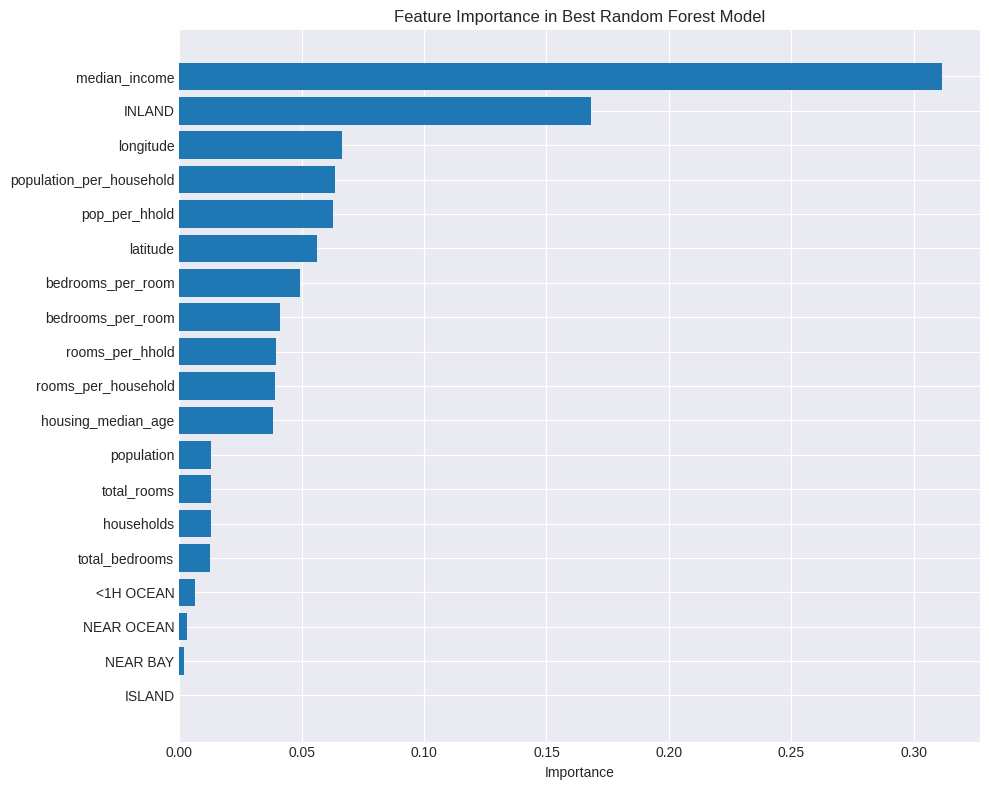

In [50]:
# Visualize feature importances
plt.figure(figsize=(10, 8))
plt.barh(range(len(feature_importance_df)), feature_importance_df['Importance'])
plt.yticks(range(len(feature_importance_df)), feature_importance_df['Feature'])
plt.xlabel('Importance')
plt.title('Feature Importance in Best Random Forest Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Key Insights**:
- `median_income` is by far the most important feature (~36%)
- Location features (longitude, latitude) are also important
- Our engineered features (rooms_per_hhold, pop_per_hhold) show good importance
- Some ocean_proximity categories have very low importance (e.g., ISLAND)

---

## 8. Final Evaluation on Test Set <a id='8-final-evaluation'></a>

**Important**: Only evaluate on test set ONCE at the very end!

In [51]:
# Get the best model
final_model = grid_search.best_estimator_

# Prepare test set
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

# Transform test data (use transform, NOT fit_transform!)
X_test_prepared = full_pipeline.transform(X_test)

# Make predictions
final_predictions = final_model.predict(X_test_prepared)

# Calculate RMSE
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

print(f"Final Test RMSE: ${final_rmse:,.2f}")

Final Test RMSE: $48,689.22


### Confidence Interval

In [52]:
# Calculate 95% confidence interval
from scipy import stats

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
confidence_interval = np.sqrt(
    stats.t.interval(confidence, len(squared_errors) - 1,
                    loc=squared_errors.mean(),
                    scale=stats.sem(squared_errors))
)

print(f"\n95% Confidence Interval: ${confidence_interval[0]:,.2f} - ${confidence_interval[1]:,.2f}")


95% Confidence Interval: $46,644.46 - $50,651.51


### Visualize Predictions vs Actual

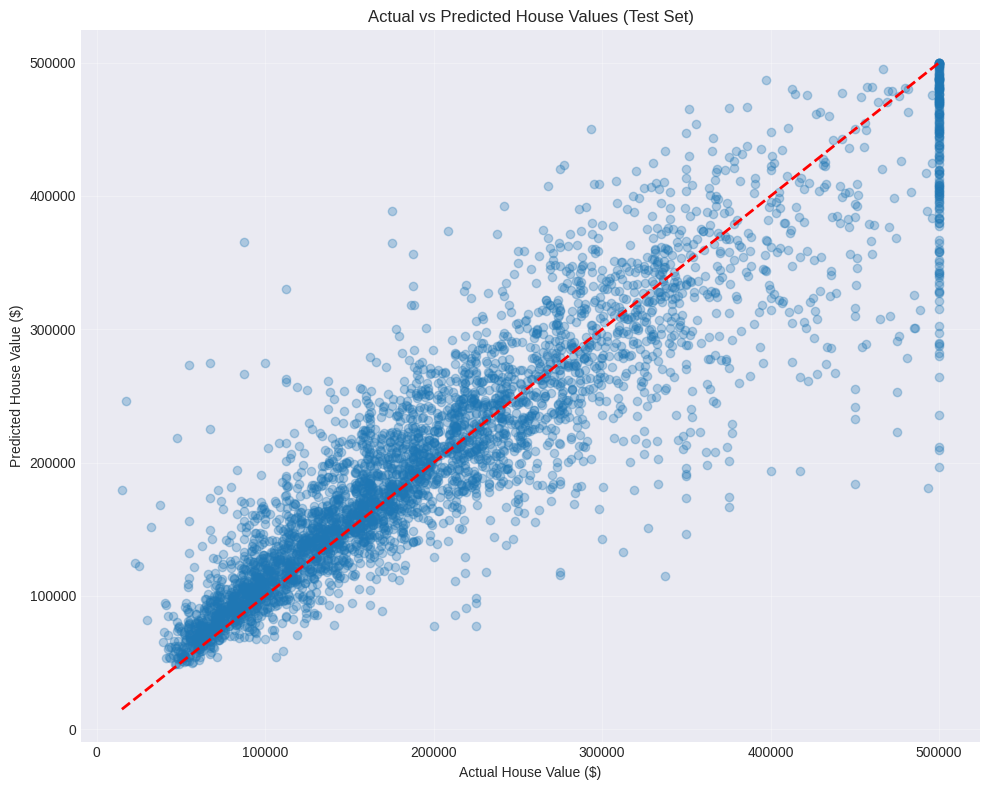

In [53]:
# Create prediction vs actual plot
plt.figure(figsize=(10, 8))
plt.scatter(y_test, final_predictions, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual House Value ($)')
plt.ylabel('Predicted House Value ($)')
plt.title('Actual vs Predicted House Values (Test Set)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

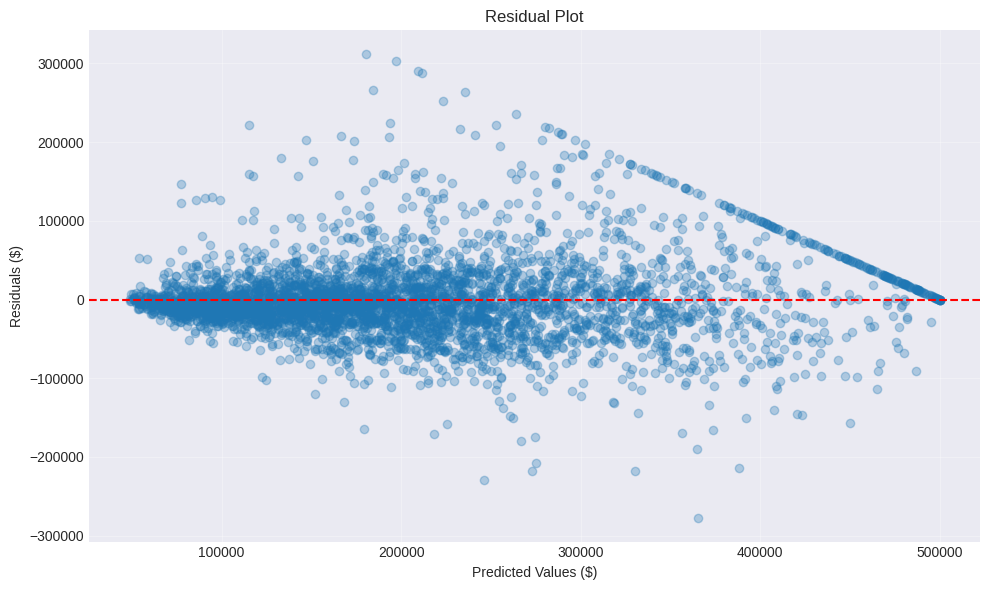

In [54]:
# Residual plot
residuals = y_test - final_predictions

plt.figure(figsize=(10, 6))
plt.scatter(final_predictions, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values ($)')
plt.ylabel('Residuals ($)')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

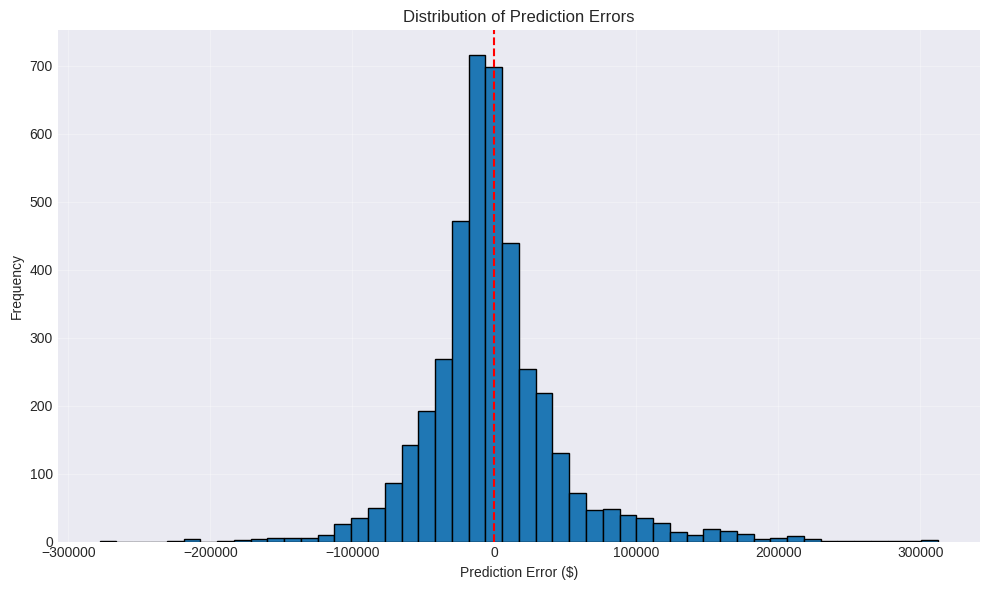

In [55]:
# Distribution of residuals
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=50, edgecolor='black')
plt.xlabel('Prediction Error ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.axvline(x=0, color='r', linestyle='--')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Summary and Key Takeaways

### Complete ML Workflow

1. **Frame the Problem**: Define objectives, constraints, and success metrics
2. **Get the Data**: Acquire and load relevant datasets
3. **Explore the Data**: EDA to understand patterns and issues
4. **Prepare the Data**: Clean, transform, and engineer features
5. **Select Models**: Try different algorithms
6. **Evaluate**: Use cross-validation for reliable estimates
7. **Fine-Tune**: Optimize hyperparameters
8. **Final Test**: Evaluate once on test set

### Important Concepts

**Regression**: Predicting continuous values

**Underfitting**: Model too simple, high training error

**Overfitting**: Model too complex, low training error but poor generalization

**Cross-Validation**: Reliable performance estimation without wasting data

**Pipelines**: Automate and standardize data transformations

**Feature Engineering**: Create new meaningful features from existing ones

**Hyperparameter Tuning**: Optimize model configuration

### Best Practices

1. **Always** create test set early and keep it separate
2. **Use stratified sampling** when important categories exist
3. **Automate data preparation** with pipelines
4. **Try multiple models** before deep diving into one
5. **Use cross-validation** for model selection
6. **Analyze feature importance** to gain insights
7. **Only evaluate on test set once** at the very end

### Model Performance Summary

| Model | Cross-Val RMSE | Test RMSE |
|-------|----------------|------------|
| Linear Regression | ~$69,052 | - |
| Decision Tree | ~$71,407 | - |
| Random Forest (default) | ~$50,182 | - |
| Random Forest (tuned) | ~$49,682 | ~$47,730 |

---

## Practice Exercises

### Exercise 1: Feature Engineering
Try creating new features based on domain knowledge:
- Distance to nearest major city
- House age categories (new, medium, old)
- Population density per square mile

### Exercise 2: Try Different Models
Implement and evaluate:
- Support Vector Regression (SVR)
- Gradient Boosting Regressor
- Neural Network (MLPRegressor)

### Exercise 3: Ensemble Methods
Create a voting regressor that combines multiple models:
```python
from sklearn.ensemble import VotingRegressor
```

### Exercise 4: Handle Outliers
- Identify outliers in the dataset
- Try removing them and see if performance improves

### Exercise 5: Feature Selection
Use the feature importance analysis to:
- Remove low-importance features
- Train a new model and compare performance

---

## Additional Resources

### Books
- *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* by Aurélien Géron
- *Introduction to Statistical Learning* by James, Witten, Hastie, and Tibshirani

### Online Resources
- Scikit-Learn Documentation: https://scikit-learn.org/
- Kaggle Learn: https://www.kaggle.com/learn
- Google's ML Crash Course: https://developers.google.com/machine-learning/crash-course

### Practice Datasets
- UCI Machine Learning Repository: https://archive.ics.uci.edu/ml/
- Kaggle Datasets: https://www.kaggle.com/datasets
- OpenML: https://www.openml.org/

---

**End of Notebook**

*Keep learning and practicing! Machine Learning is a journey, not a destination.* 🚀